# Проект. Исследование стартапов

## Введение

Финансовая компания, работающая с венчурными инвестициями, хочет понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний. Для этого необходимо провести исследование на исторических данных. Вы поработаете с информацией о компаниях, объёмах и типах привлечённых инвестиций, а также с дополнительной статистикой по возвратам средств.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.



### 1.1. Вывод общей информации

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Загружаем данные
df_read_orig = pd.read_csv("секретная_информация/cb_investments.zip", sep=';', low_memory=False)
df_cb_returns_orig = pd.read_csv("секретная_информация/cb_returns.csv", index_col = 'year')

# Создадим копии датафреймов
df_read = df_read_orig.copy()
df_cb_returns = df_cb_returns_orig.copy()

In [3]:
# Выведем инормацию о данных
display(df_read.info())
display(df_cb_returns.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

None

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  product_crowdfunding  15 non-null     float64
dtypes: float64(13)
memory usage: 1.6 KB


None

Выведите информацию, которая необходима для принятия решений о предобработке.

In [4]:
# Выведем первые 5 строк датафреймов
display(df_read.head())
display(df_cb_returns.head())

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [5]:
# Посчитаем количество пропусков в каждом столбце, а так же долю
df_missing_read = pd.DataFrame({'num_missing': df_read.isna().sum(),
                                'share_missing': (df_read.isna().mean()*100).round(2)}).sort_values(by='num_missing', ascending=False)
df_missing_cb_returns = pd.DataFrame({'num_missing': df_cb_returns.isna().sum(),
                                     'share_missing': (df_cb_returns.isna().mean()*100).round(2)}).sort_values(by='num_missing', ascending=False)

# Выведем на экран
display(df_missing_read)
display(df_missing_cb_returns)

,num_missing,share_missing
state_code,24133,44.45
mid_funding_at,24006,44.21
participants,23821,43.87
founded_month,15812,29.12
founded_quarter,15812,29.12
founded_at,15740,28.99
founded_year,15740,28.99
city,10972,20.21
country_code,10129,18.66
region,10129,18.66


,num_missing,share_missing
seed,0,0.0
venture,0,0.0
equity_crowdfunding,0,0.0
undisclosed,0,0.0
convertible_note,0,0.0
debt_financing,0,0.0
angel,0,0.0
grant,0,0.0
private_equity,0,0.0
post_ipo_equity,0,0.0


In [6]:
# Посомотрим на типы данных
display(df_read.dtypes)
display(df_cb_returns.dtypes)

name                     object
homepage_url             object
category_list            object
 market                  object
 funding_total_usd       object
status                   object
country_code             object
state_code               object
region                   object
city                     object
funding_rounds          float64
participants            float64
founded_at               object
founded_month            object
founded_quarter          object
founded_year            float64
first_funding_at         object
mid_funding_at           object
last_funding_at          object
seed                    float64
venture                 float64
equity_crowdfunding     float64
undisclosed             float64
convertible_note        float64
debt_financing          float64
angel                   float64
grant                   float64
private_equity          float64
post_ipo_equity         float64
post_ipo_debt           float64
secondary_market        float64
product_

seed                    float64
venture                 float64
equity_crowdfunding     float64
undisclosed             float64
convertible_note        float64
debt_financing          float64
angel                   float64
grant                   float64
private_equity          float64
post_ipo_equity         float64
post_ipo_debt           float64
secondary_market        float64
product_crowdfunding    float64
dtype: object

### Промежуточный вывод
В данных присутствуют пропуски в больших количествах, необходимость заполнения определим в дальнейшем.   
Многие типы данных не соответствуют содержимому. В именах двух столбцов есть лишние пробелы. 

### 1.2. Предобработка данных

In [7]:
# Выведем имена всех столбцов
print(df_read.columns)
print(df_cb_returns.columns)

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')
Index(['seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')


In [8]:
# Удалим лишние пробелы в именах столбцов, приведем к нижнему регистру
df_read.columns = df_read.columns.str.strip().str.lower().str.replace(' ', '_')
df_cb_returns.columns = df_cb_returns.columns.str.strip().str.lower().str.replace(' ', '_')


In [9]:
# Проверим изменения
print(df_read.columns)
print(df_cb_returns.columns)

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')
Index(['seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')


In [10]:
# Выведем столбец 'funding_total_usd' на экран
display(df_read['funding_total_usd'])

0         9,00,00,000 
1           20,00,000 
2           90,00,000 
3           77,00,000 
4            5,40,000 
             ...      
54289              NaN
54290              NaN
54291              NaN
54292              NaN
54293              NaN
Name: funding_total_usd, Length: 54294, dtype: object

In [11]:
# Уберем разрядность у столбца 'funding_total_usd', приведем к числовому типу
df_read['funding_total_usd_clean'] = (df_read['funding_total_usd'].astype(str)
                                      .str.replace('-', '', regex=False)
                                      .str.replace(',', '', regex=False)
                                      .str.strip() )

df_read['funding_total_usd'] = pd.to_numeric(df_read['funding_total_usd_clean'], errors='coerce')

# Удалим временный столбец
df_read = df_read.drop(columns=['funding_total_usd_clean'])


In [12]:
# Проверим изменения
print(df_read['funding_total_usd'])

0        90000000.0
1         2000000.0
2         9000000.0
3         7700000.0
4          540000.0
            ...    
54289           NaN
54290           NaN
54291           NaN
54292           NaN
54293           NaN
Name: funding_total_usd, Length: 54294, dtype: float64


In [13]:
# Преобразуем столбцы с датами
date_cols = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']
for c in date_cols:
    df_read[c] = pd.to_datetime(df_read[c], format='%Y-%m-%d', errors='coerce')

# Преобразуем месяц
df_read['founded_month'] = (
    pd.to_datetime(df_read['founded_month'], format='%Y-%m', errors='coerce')
      .dt.to_period('M')
)

# Преобразуем квартал
fmtd_q = (df_read['founded_quarter']
          .astype(str)
          .str.strip()
          .str.replace('-Q', 'Q', regex=False)
          .replace({'<NA>': None, 'nan': None, 'NaT': None})
         )
df_read['founded_quarter'] = pd.PeriodIndex(fmtd_q, freq='Q')

# Преобразуем год
df_read['founded_year'] = pd.to_numeric(df_read['founded_year'], errors='coerce').astype('Int64')




In [14]:
# Проверим изменения
display(df_read[date_cols + ['founded_month', 'founded_quarter', 'founded_year']].dtypes)


founded_at          datetime64[ns]
first_funding_at    datetime64[ns]
mid_funding_at      datetime64[ns]
last_funding_at     datetime64[ns]
founded_month            period[M]
founded_quarter      period[Q-DEC]
founded_year                 Int64
dtype: object

In [15]:
# Приведем столбцы name, homepage_url, country_code, region, city, category_list, market, status, state_code к строковому типу
str_cols = ['name', 'homepage_url', 'country_code', 'region', 'city', 'category_list', 'market', 'status', 'state_code']
for c in str_cols:
    df_read[c] = df_read[c].astype('string')
    
# Проверим изменения
display(df_read[str_cols].dtypes)

name             string[python]
homepage_url     string[python]
country_code     string[python]
region           string[python]
city             string[python]
category_list    string[python]
market           string[python]
status           string[python]
state_code       string[python]
dtype: object

In [16]:
# Посчитаем количество пропусков в str_cols
df_missing_str = pd.DataFrame({'num_missing': df_read[str_cols].isna().sum(),
                               'share_missing': (df_read[str_cols].isna().mean()*100).round(2)}).sort_values(by='num_missing', ascending=False)

display(df_missing_str)

,num_missing,share_missing
state_code,24133,44.45
city,10972,20.21
country_code,10129,18.66
region,10129,18.66
category_list,8817,16.24
market,8817,16.24
homepage_url,8305,15.30
status,6170,11.36
name,4857,8.95


In [17]:
# Заменим пропуски в столбцах str_cols на 'unknown'
df_read[str_cols] = df_read[str_cols].fillna('unknown')

# Проверим изменения
df_missing_str_after = pd.DataFrame({'num_missing': df_read[str_cols].isna().sum(),
                                     'share_missing': (df_read[str_cols].isna().mean()*100).round(2)}).sort_values(by='num_missing', ascending=False)
display(df_missing_str_after)

,num_missing,share_missing
name,0,0.0
homepage_url,0,0.0
country_code,0,0.0
region,0,0.0
city,0,0.0
category_list,0,0.0
market,0,0.0
status,0,0.0
state_code,0,0.0


In [18]:
# Проверим данные на наличие полных дубликатов
print(df_read.duplicated().sum())

# Удалим полные дубликаты
df_read = df_read.drop_duplicates()

# Проверим изменения
print(df_read.duplicated().sum())


4855
0


In [19]:
# Проверим столбец 'funding_total_usd'. Если есть пропуск в ячейке 'funding_total_usd', проверяем значения 
# в 'seed', 'venture', 'equity_crowdfunding', 'debt_financing', 'convertible_note', 'undisclosed', 'grant', 'private_equity', 
# 'post_ipo_debt', 'post_ipo_equity', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 
# 'round_E', 'round_F', 'round_G', 'round_H'. Если в этих столбцах есть значение, то заполняем пропуск в 'funding_total_usd' 
# суммой этих значений. Если в этих столбцах нет значений, удаляем строку. Если в 'funding_total_usd' есть значение, оставляем его без изменений.
funding_types = ['seed', 'venture', 'equity_crowdfunding', 
                 'debt_financing', 'convertible_note', 'undisclosed', 
                 'grant', 'private_equity', 'post_ipo_debt', 
                 'post_ipo_equity', 'secondary_market', 'product_crowdfunding', 
                 'round_a', 'round_b', 'round_c', 
                 'round_d', 'round_e', 'round_f', 
                 'round_g', 'round_h']

for c in funding_types:
    df_read[c] = pd.to_numeric(df_read[c], errors='coerce') 
    df_read[c] = df_read[c].fillna(0)

# Заполним пропуски в 'funding_total_usd'
mask_missing_funding = df_read['funding_total_usd'].isna()
df_read.loc[mask_missing_funding, 'funding_total_usd'] = df_read.loc[mask_missing_funding, funding_types].sum(axis=1)
df_read = df_read.dropna(subset=['funding_total_usd'])

# Удалим данные из столбца 'funding_total_usd', которые меньше 10000
df_read = df_read[df_read['funding_total_usd'] >= 10000]

# Приведем столбцы funding_total_usd к целочисленному типу
df_read['funding_total_usd'] = df_read['funding_total_usd'].astype('int64')

# Проверим изменения
print(df_read['funding_total_usd'].isna().sum())


0


In [20]:
# Заполним пропуски 'mid_funding_at' как середину между first_funding_at и last_funding_at
mid_funding_interval = (df_read['last_funding_at'] - df_read['first_funding_at']) / 2
if df_read['mid_funding_at'].isna().sum() > 0:
    df_read.loc[df_read['mid_funding_at'].isna(), 'mid_funding_at'] = df_read['first_funding_at'] + mid_funding_interval

# Посчитаем количество оставшихся пропусков в этом столбце
print(df_read['mid_funding_at'].isna().sum())


1


In [21]:
# Посчитаем количество пропусков в датафрейме df_read
df_missing_total = pd.DataFrame({'num_missing': df_read.isna().sum(),
                                 'share_missing': (df_read.isna().mean()*100).round(2)}).sort_values(by='num_missing', ascending=False)
display(df_missing_total)


,num_missing,share_missing
participants,13337,32.91
founded_quarter,8736,21.56
founded_month,8736,21.56
founded_at,8672,21.40
founded_year,8671,21.40
first_funding_at,2,0.00
mid_funding_at,1,0.00
grant,0,0.00
private_equity,0,0.00
post_ipo_equity,0,0.00


In [22]:
# Посчитаем, сколько строк было удалено
print(f"Количество строк в исходном датафрейме: {df_read_orig.shape[0]}")
print(f"Количество строк в очищенном датафрейме: {df_read.shape[0]}")
print(f"Количество удаленных строк: {df_read_orig.shape[0] - df_read.shape[0]}")
print(f"Процент удаленных строк: {round((df_read_orig.shape[0] - df_read.shape[0]) / df_read_orig.shape[0] * 100, 2)}%")

Количество строк в исходном датафрейме: 54294
Количество строк в очищенном датафрейме: 40528
Количество удаленных строк: 13766
Процент удаленных строк: 25.35%


### Промежуточный вывод

Было удалено 25% строк из-за отсутствия данных в ключевых столбцах. Были преобразованы типы данных, заполнены пропуски в строковых столбцах заглушками "unknown",   
а пропуски в столбце "funding_total_usd" заполнены суммой значений из других столбцов. Пропуски в столбце "mid_funding_at" заполнены как середина между "first_funding_at" и "last_funding_at".   
Однако все еще остаются пропуски, в столбцах о дате основания компании: "founded_at", "founded_month", "founded_quarter", "founded_year". Решение по ним будет принято позже, если это потребуется для анализа.

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Формируется три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализация:

* По количеству компаний
* По объёму инвестиций

In [23]:
# Добавим нвоый столбец 'financing_periods'. Если у компании встречается только один раунд финансирования - присвоим категорию "Единичное финаснирование",
# если срок финансирования до года - "Срок финасирования до года", если более года - "Срок финасирования более года". 
# Столбцы для расчетов раунда финансирования - от 'seed' до 'round_h'.
funding_round_cols = ['seed', 'venture', 'equity_crowdfunding', 
                      'debt_financing', 'convertible_note', 'undisclosed', 
                      'grant', 'private_equity', 'post_ipo_debt', 
                      'post_ipo_equity', 'secondary_market', 'product_crowdfunding', 
                      'round_a', 'round_b', 'round_c', 
                      'round_d', 'round_e', 'round_f', 
                      'round_g', 'round_h'] 

def categorize_financing_periods(row):
    if row['funding_rounds'] == 1:
        return "Единичное финансирование"
    elif pd.notna(row['first_funding_at']) and pd.notna(row['last_funding_at']):
        funding_duration = (row['last_funding_at'] - row['first_funding_at']).days
        if funding_duration <= 365:
            return "Срок финансирования до года"
        else:
            return "Срок финансирования более года"
    else:
        return "Неизвестно"

# Применим функцию к каждой строке
df_read['financing_periods'] = df_read.apply(categorize_financing_periods, axis=1)


In [24]:
# посчитаем количество компаний в каждой категории 'financing_periods'
financing_periods_counts = df_read['financing_periods'].value_counts()
print(financing_periods_counts)



financing_periods
Единичное финансирование          23746
Срок финансирования более года    12289
Срок финансирования до года        4491
Неизвестно                            2
Name: count, dtype: int64


In [25]:
# Так как всего 2 компании в категории "Неизвестно", а в "Срок финансирования до года" - 4501,  изменим "Неизвестно" на "Срок финансирования до года"
df_read['financing_periods'] = df_read['financing_periods'].replace({'Неизвестно': 'Срок финансирования до года'})

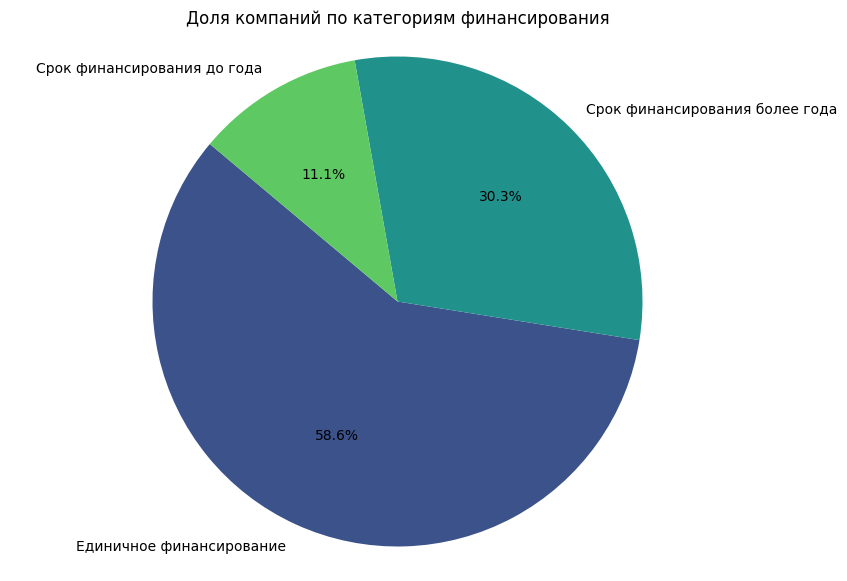

In [26]:
# отобразим на круговой диаграмме долю каждой категории от общего числа компаний
financing_periods_share = (df_read['financing_periods'].value_counts(normalize=True) * 100).round(2)

plt.figure(figsize=(10, 7))
plt.pie(financing_periods_share, 
        labels=financing_periods_share.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('viridis', len(financing_periods_share)))
plt.title('Доля компаний по категориям финансирования')
plt.axis('equal')
plt.show()

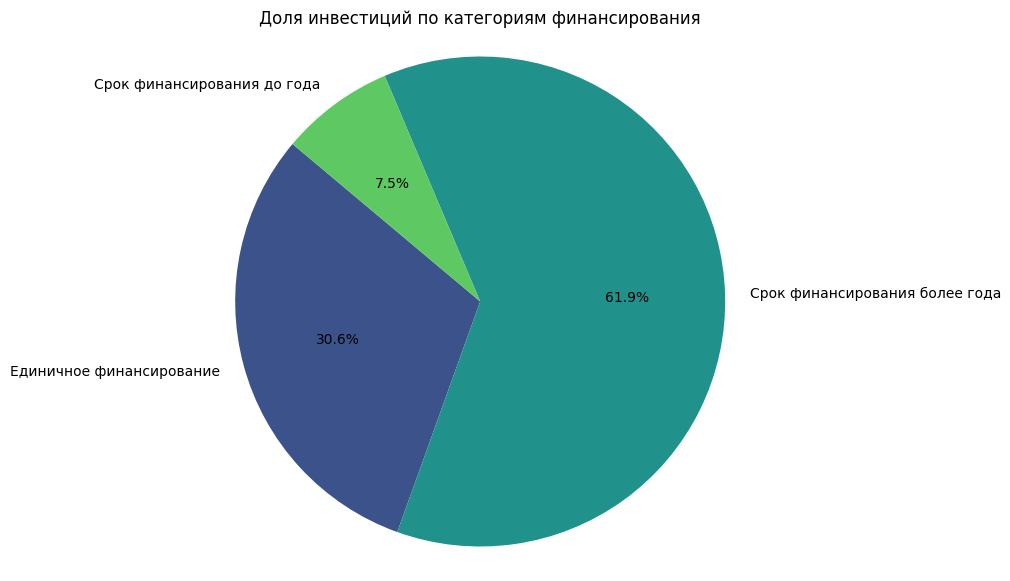

In [27]:
# Создадим круговую диаграмму, выразив долю инвестиций в каждой категории 'financing_periods' от общего объема инвестиций
financing_periods_investments = df_read.groupby('financing_periods')['funding_total_usd'].sum()
financing_periods_investments_share = financing_periods_investments / financing_periods_investments.sum() * 100

plt.figure(figsize=(10, 7))
plt.pie(financing_periods_investments_share, 
        labels=financing_periods_investments_share.index, 
        autopct='%1.1f%%', startangle=140, 
        colors=sns.color_palette('viridis', len(financing_periods_investments_share)))
plt.title('Доля инвестиций по категориям финансирования')
plt.axis('equal')
plt.show()

## Промежуточный вывод
В данных отсутствовали даты первого финансирования для двух компаний, что не позволило отнести их к какой-либо группе.   
Для исключения группы "Неизвестно" из дальнейшего анализа, так как в ней всего 2 компании, заменим её на "Срок финансирования до года", в которой 4501 компания.   
Это не окажет влияния на анализ, т.к. число компаний группы "Неизвестно" слишком незначительно.  
По результатам анализа выяснили, что большинство компании (58,6%) имеют единичное финансирование, а так же эти же компании имеют 30,6% от всего объема инвестиций.   
30,3% компаний имеют срок финансирования более года, у этой же группы 61,9% от всего объема инвестиций.   
11,1% компаний имеют срок финансирования до года, у этой же группы 7,5% от всего объема инвестиций.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

In [28]:
# Удалим лишние пробелы в столбце 'market'
df_read['market'] = df_read['market'].str.strip()

In [29]:
# Сначала посчитаем количество компаний в каждой отрасли ('market')
market_counts = df_read['market'].value_counts()

# Определим категории сегментов для каждой отрасли
def categorize_market_segment(market_name):
    count = market_counts.get(market_name, 0)
    if count > 120:
        return "Массовый сегмент"
    elif 35 <= count <= 120:
        return "Средний сегмент"
    else:
        return "Нишевый сегмент"

# Создаем словарь соответствия отрасли к сегменту
market_to_segment = {market: categorize_market_segment(market) for market in market_counts.index}

# Добавляем новый столбец 'market_segment' на основе значений в 'market'
df_read['market_segment'] = df_read['market'].map(market_to_segment)

# Посчитаем количество компаний в каждой категории 'market_segment'
market_segment_counts = df_read['market_segment'].value_counts()
print("Количество компаний в каждой категории:")
print(market_segment_counts)

# Также создадим переменную market_segments для дальнейшего использования
market_segments = df_read.groupby('market')['market_segment'].first()
print(f"\nКоличество отраслей в каждом сегменте:")
print(market_segments.value_counts())


Количество компаний в каждой категории:
market_segment
Массовый сегмент    35905
Средний сегмент      3801
Нишевый сегмент       822
Name: count, dtype: int64

Количество отраслей в каждом сегменте:
market_segment
Нишевый сегмент     287
Средний сегмент      57
Массовый сегмент     49
Name: count, dtype: int64


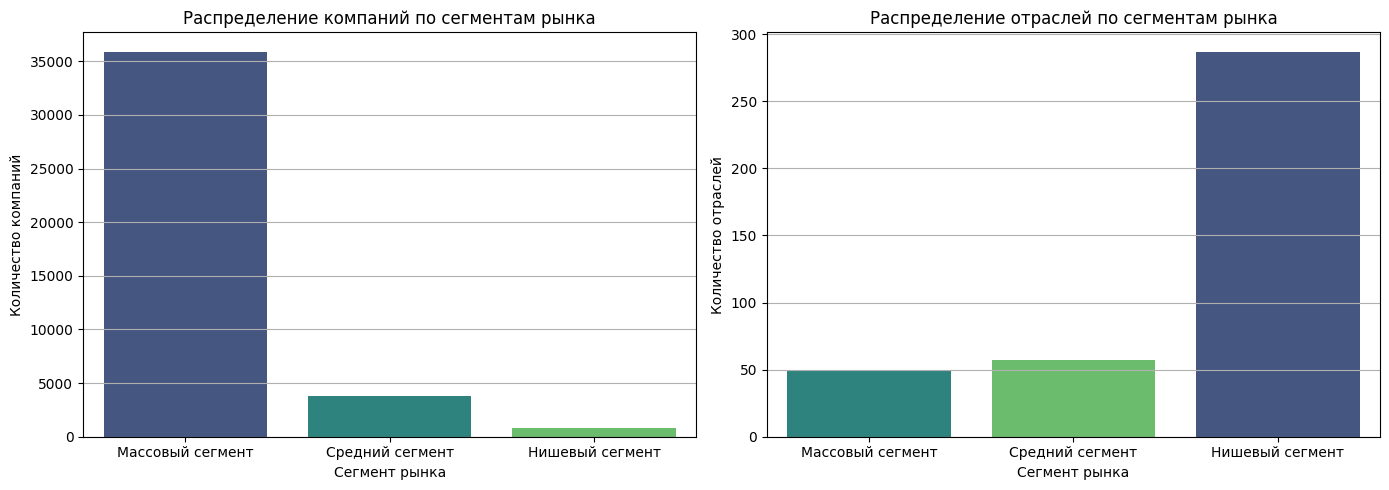

In [30]:
# Выведем столбчатую диаграмму, отобразив количество компаний в каждом сегменте
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df_read, x='market_segment', order=market_segment_counts.index, palette='viridis', hue = 'market_segment', legend=False)
plt.title('Распределение компаний по сегментам рынка')
plt.xlabel('Сегмент рынка')
plt.ylabel('Количество компаний')
plt.grid(axis='y')


plt.subplot(1, 2, 2)
sns.countplot(data=df_read, x=market_segments, order=market_segment_counts.index, palette='viridis', hue = market_segments, legend=False)
plt.title('Распределение отраслей по сегментам рынка')
plt.xlabel('Сегмент рынка')
plt.ylabel('Количество отраслей')
plt.grid(axis='y')

plt.tight_layout()
plt.show()

In [31]:
''' 
Заменим значения в столбце 'market'.
Если компания относится к "Массовому сегменту", оставим значение в 'market' без изменений.
Если компания относится к "Среднему сегменту", заменим значение в 'market' на "Средний сегмент".
Если компания относится к "Нишевому сегменту", заменим значение в 'market' на "Нишевый сегмент".
'''
def replace_market_segment(row):
    if row['market'] in market_segments[market_segments == 'Массовый сегмент'].index:
        return row['market']
    elif row['market'] in market_segments[market_segments == 'Средний сегмент'].index:
        return 'mid'
    elif row['market'] in market_segments[market_segments == 'Нишевый сегмент'].index:
        return 'niche'
    else:
        return row['market']
    
df_read['market'] = df_read.apply(replace_market_segment, axis=1)

display(df_read['market'].value_counts())

market
Software                4787
mid                     3801
Biotechnology           3585
unknown                 2462
Mobile                  2330
E-Commerce              1847
Curated Web             1675
Enterprise Software     1378
Health Care             1184
Clean Technology        1175
Games                   1110
Advertising             1099
Hardware + Software     1060
Social Media             980
Health and Wellness      869
Education                832
Finance                  824
niche                    822
Analytics                667
Manufacturing            593
Security                 567
Semiconductors           484
Web Hosting              422
Travel                   328
Hospitality              327
Consulting               324
Messaging                295
Fashion                  294
News                     292
Search                   285
Real Estate              272
SaaS                     271
Music                    259
Internet                 239
Technol


### Промежуточный вывод

По результатам анализа можно сделать следующие выводы:   
    - Массовый сегмент занимают 49 отраслей и 35905 компаний.   
    - Средний сегмент занимают 57 отраслей и 3801 компания.    
    - Нишевый сегмент занимают 287 отраслей и 822 компании.   
    
По требованию задания, отрасли для массового сегмента остались без изменений,    
все остальные отрасли были заменены на нишевый и средний сегмент. 

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

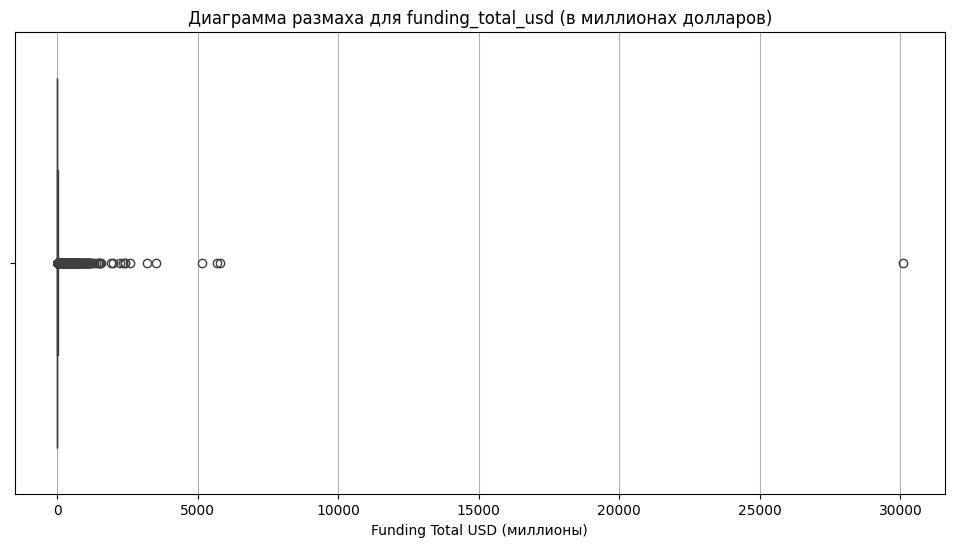

In [34]:
# Построим диаграмму размаха для визуализации аномальных значений и выбросов в столбце 'funding_total_usd' (в миллионах)
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_read['funding_total_usd'] / 1_000_000)
plt.title('Диаграмма размаха для funding_total_usd (в миллионах долларов)')
plt.xlabel('Funding Total USD (миллионы)')
plt.grid(axis='x')
plt.show()


В данных присутствуют аномальные значения и выбросы. Отфильтруем результат и визуализируем изменения.

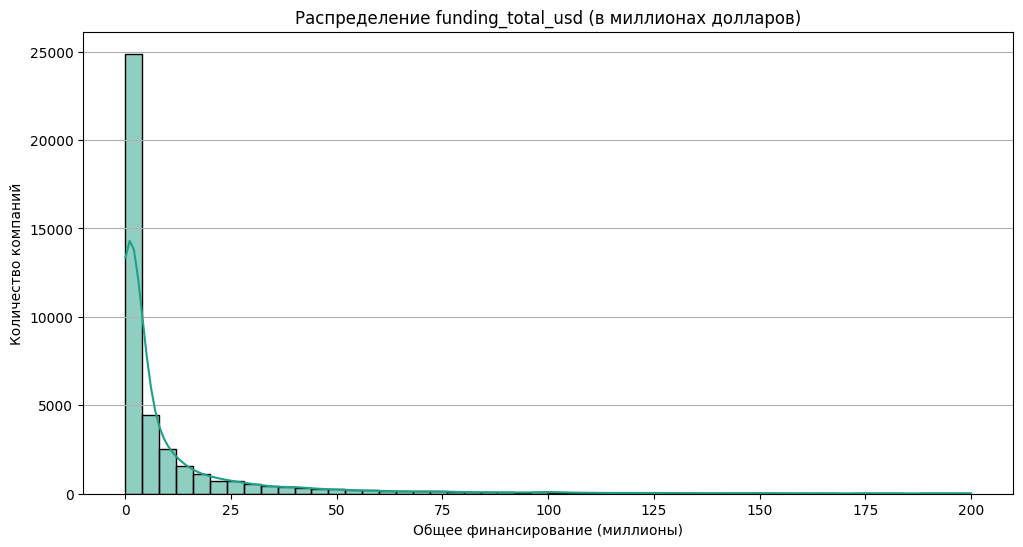

In [35]:
# Для фильтрации выбросов отфильтруем данные выше 0,99-го перцентиля
percentile_99 = df_read['funding_total_usd'].quantile(0.99)


# Построим гистрограмму распределения значений в столбце 'funding_total_usd' (в миллионах), отфильтровав 0,99 перцентиль
plt.figure(figsize=(12, 6))
sns.histplot((df_read['funding_total_usd'].loc[df_read['funding_total_usd'] <= percentile_99]) / 1_000_000, bins=50, kde=True, color=sns.color_palette('viridis')[3])
plt.title('Распределение funding_total_usd (в миллионах долларов)')
plt.xlabel('Общее финансирование (миллионы)')
plt.ylabel('Количество компаний')
plt.grid(axis='y')
plt.show()

In [36]:
# Разобьем данные на группы по funding_total_usd до 200 млн, что бы соотнести количество компаний и уровни финансирования
def categorize_funding_level(funding):
    if funding < 1_000_000:
        return 'до 1 млн'
    elif 1_000_000 <= funding < 10_000_000:
        return 'от 1 до 10 млн'
    elif 10_000_000 <= funding < 50_000_000:
        return 'от 10 до 50 млн'
    elif 50_000_000 <= funding < 75_000_000:
        return 'от 50 до 75 млн'
    elif 75_000_000 <= funding < 100_000_000:
        return 'от 75 до 100 млн'
    elif 100_000_000 <= funding < 150_000_000:
        return 'от 100 до 150 млн'
    elif 150_000_000 <= funding < 200_000_000:
        return 'от 150 до 200 млн'
    else:
        return 'более 200 млн'
df_read['funding_level'] = df_read['funding_total_usd'].apply(categorize_funding_level)
# Посчитаем количество компаний в каждой категории funding_level
funding_level_counts = df_read['funding_level'].value_counts().sort_index()
print("Количество компаний в каждой категории funding_level:")
display(funding_level_counts)


Количество компаний в каждой категории funding_level:


funding_level
более 200 млн          414
до 1 млн             15022
от 1 до 10 млн       15264
от 10 до 50 млн       7670
от 100 до 150 млн      506
от 150 до 200 млн      163
от 50 до 75 млн        999
от 75 до 100 млн       490
Name: count, dtype: int64

### Промежуточный вывод

После фильтрации можно выделить границы типичных значений:   
от 10 тыс до 50 млн долларов.    
Большая часть компаний имеет финансирование около 1 и 10 млн долларов. Точные цифры представлены ниже. 
| Категория | Количество компаний |
|----------|----------------------:|
| до 1 млн | 15022 |   
| от 1 до 10 млн | 15264 |    
| от 10 до 50 млн | 7670 | 
|от 50 до 75 млн|        999 |
|от 75 до 100 млн|       490 |
|от 100 до 150 млн|      506 |
|от 150 до 200 млн|      163 |
|более 200 млн|          414 |



In [37]:
# Функция для определения аномальных значений с использованием IQR
def identify_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data < lower_bound) | (data > upper_bound)

# Применим метод IQR отдельно по каждому сегменту рынка
outliers_by_segment = pd.Series(False, index=df_read.index)
for segment in df_read['market'].unique():
    segment_mask = df_read['market'] == segment
    outliers_segment = identify_outliers_iqr(df_read.loc[segment_mask, 'funding_total_usd'])
    outliers_by_segment.loc[segment_mask] = outliers_segment

# Определяем сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование
outlier_segments = (df_read.loc[outliers_by_segment, 'market'].value_counts() /
                    df_read['market'].value_counts() * 100).round(2)
print("Доля компаний с аномальным объемом финансирования по сегментам рынка (%):")
display(outlier_segments.sort_values(ascending=False))


# Определим топ 5 сегментов
top_5_outlier_segments = outlier_segments.sort_values(ascending=False).head(5)


Доля компаний с аномальным объемом финансирования по сегментам рынка (%):


market
Real Estate             17.28
Cloud Computing         16.45
Entertainment           16.31
SaaS                    16.24
Technology              16.10
Video                   15.96
Search                  15.79
Marketplaces            15.62
niche                   15.57
Networking              15.56
Travel                  15.55
Internet                15.48
Photography             15.35
Big Data                15.33
Consulting              14.81
Automotive              14.67
unknown                 14.50
E-Commerce              14.46
mid                     14.42
Apps                    14.41
Social Media            13.88
Sports                  13.50
Startups                13.18
Mobile                  13.05
News                    13.01
Health and Wellness     13.00
Messaging               12.88
Hospitality             12.84
Clean Technology        12.77
Music                   12.74
Social Network Media    12.66
Education               12.62
Analytics               12.29
Pub

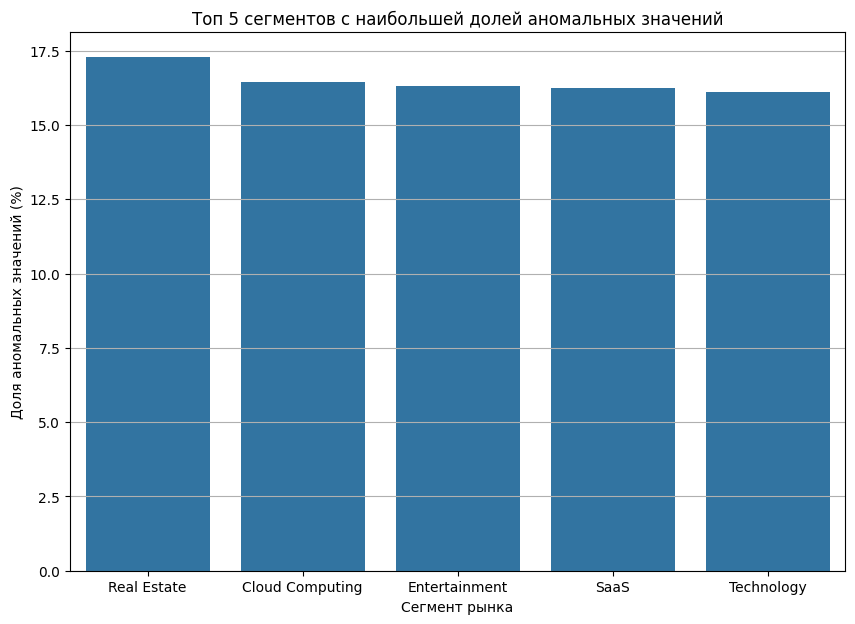

In [58]:
# Построим  столбчатую диаграмму для топ 5
plt.figure(figsize=(10, 7))
sns.barplot(x=top_5_outlier_segments.index, y=top_5_outlier_segments.values)
plt.title('Топ 5 сегментов с наибольшей долей аномальных значений')
plt.xlabel('Сегмент рынка')
plt.ylabel('Доля аномальных значений (%)')
plt.grid(axis='y')
plt.show()


### Промежуточный вывод

Топ - 1 аномального финансирования занимает сегмент Real Estate - 17,2%     
На втором месте Cloud Computing - 16,4%    
На третьем месте Entertainment - 16,3%   


### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

In [39]:
# Выведем количество записей по месяцам за 2014 год
df_2014 = df_read[df_read['mid_funding_at'].dt.year == 2014]
monthly_counts_2014 = df_2014['mid_funding_at'].dt.month.value_counts().sort_index()
print("Количество записей по месяцам за 2014 год:")
display(monthly_counts_2014)

Количество записей по месяцам за 2014 год:


mid_funding_at
1     721
2     585
3     663
4     635
5     579
6     718
7     671
8     545
9     533
10    488
11    305
12     23
Name: count, dtype: int64

In [40]:
# Используем только те данные, которые фильтровались по методу IQR
df_filtered = df_read[~identify_outliers_iqr(df_read['funding_total_usd'])] 

# Извлекаем год из столбца 'mid_funding_at'
df_filtered['funding_year'] = df_filtered['mid_funding_at'].dt.year

# Считаем количество раундов финансирования по годам
funding_rounds_per_year = df_filtered.groupby('funding_year')['funding_rounds'].sum()

# Фильтруем года, оставляя только те, где количество раундов финансирования больше 50
funding_rounds_per_year_filtered_50 = funding_rounds_per_year[funding_rounds_per_year > 50]

# Оставляем компании, у которых год финансирования в отфильтрованных годах
df_filtered = df_filtered[df_filtered['funding_year'].isin(funding_rounds_per_year_filtered_50.index)]

# Проверим изменения
display(df_filtered.info())



<class 'pandas.core.frame.DataFrame'>
Index: 35250 entries, 1 to 49437
Data columns (total 44 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  35250 non-null  string        
 1   homepage_url          35250 non-null  string        
 2   category_list         35250 non-null  string        
 3   market                35250 non-null  object        
 4   funding_total_usd     35250 non-null  int64         
 5   status                35250 non-null  string        
 6   country_code          35250 non-null  string        
 7   state_code            35250 non-null  string        
 8   region                35250 non-null  string        
 9   city                  35250 non-null  string        
 10  funding_rounds        35250 non-null  float64       
 11  participants          22845 non-null  float64       
 12  founded_at            27491 non-null  datetime64[ns]
 13  founded_month        

/var/folders/r6/hdcb05w55xd6zd0lk_pwxdp00000gn/T/ipykernel_82897/4255571378.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['funding_year'] = df_filtered['mid_funding_at'].dt.year


None

### Промежуточный вывод

Т.к. в данных за 2014 год в декабре всего 23 записи, можно сделать вывод, что данные за этот год неполные.    
После удаления аномальных значений и отбора компаний с 50 и более раундами финансирования, данные готовы для дальнейшего анализа.

### 3.3. Анализ типов финансирования по объёму и популярности

In [41]:
# Создадим список столбцов для анализа 
# `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, 
# `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`
funding_type_cols = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing',
                     'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

In [42]:
# Создадим табдицу, что бы определить, какой тип финансирования привлек больше всего денег
funding_type_summary = df_read[funding_type_cols].sum().sort_values(ascending=False)
print("Суммарное финансирование по типам:")
display(funding_type_summary)

Суммарное финансирование по типам:


venture                 3.708368e+11
private_equity          1.025485e+11
debt_financing          9.334661e+10
post_ipo_equity         3.010150e+10
post_ipo_debt           2.192259e+10
seed                    1.074321e+10
grant                   8.050668e+09
undisclosed             6.437847e+09
angel                   3.234117e+09
secondary_market        1.901184e+09
convertible_note        1.155038e+09
product_crowdfunding    3.497246e+08
equity_crowdfunding     3.044513e+08
dtype: float64

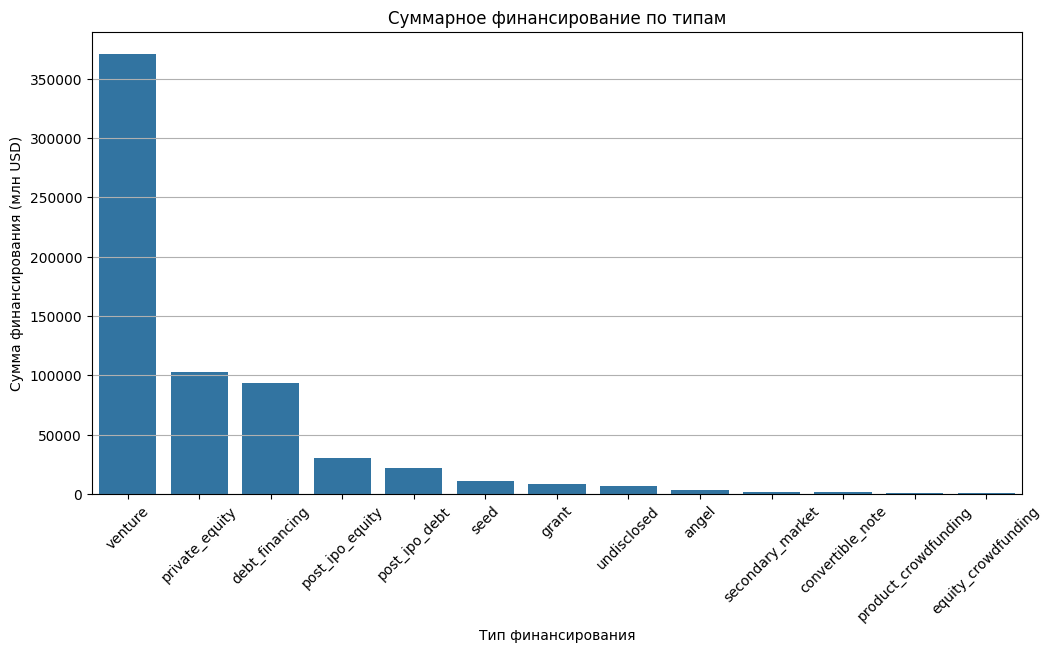

In [59]:
# Построим столбчатую диаграмму для визуализации, сумму укажем в миллионах долларов
plt.figure(figsize=(12, 6))
sns.barplot(x=funding_type_summary.index, y=funding_type_summary.values / 1_000_000)
plt.title('Суммарное финансирование по типам')
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма финансирования (млн USD)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [44]:
# Проверим популярность типов финансирования, для этого посчитаем общее количество финансирований
funding_type_popularity = (df_read[funding_type_cols] > 0).sum().sort_values(ascending=False)
print("Популярность типов финансирования (количество раундов):")
display(funding_type_popularity)

Популярность типов финансирования (количество раундов):


venture                 23242
seed                    13678
debt_financing           4202
angel                    3112
private_equity           1369
grant                    1122
undisclosed               944
convertible_note          543
equity_crowdfunding       430
post_ipo_equity           316
product_crowdfunding      207
post_ipo_debt              75
secondary_market           19
dtype: int64

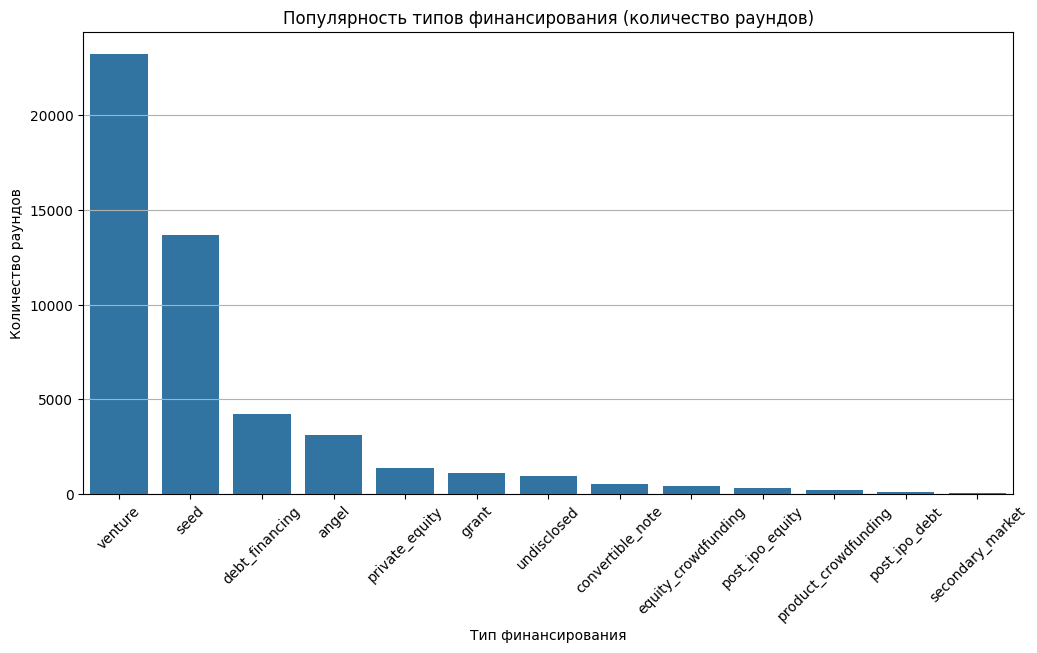

In [60]:
# Отобразим на столбчатой диаграмме
plt.figure(figsize=(12, 6))
sns.barplot(x=funding_type_popularity.index, y=funding_type_popularity.values)
plt.title('Популярность типов финансирования (количество раундов)')
plt.xlabel('Тип финансирования')
plt.ylabel('Количество раундов')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Промежуточный вывод
Чаще всего используются типы финансирования: `venture`, `seed` и `debt_financing`.
Они же привлекают наибольшие суммы финансирования.

Если рассматривать непопулярные типы финансирования, но с большими суммами, то можно выделить `private_equity` и `post_ipo_equity`.

Из популярных типов финансирования с небольшими суммами можно выделить `grant` и `convertible_note`.

In [46]:
# Посчитаем суммарный объем возвратов по типам финансирования из df_cb_returns
cb_returns_summary = df_cb_returns.sum().sort_values(ascending=False)
print("Суммарный объем возвратов по типам финансирования:")
display(cb_returns_summary)

Суммарный объем возвратов по типам финансирования:


venture                 40578.62
debt_financing           4734.85
private_equity           3587.33
seed                     2382.24
angel                    1509.23
post_ipo_equity          1104.96
undisclosed               730.88
post_ipo_debt              91.03
convertible_note           34.79
secondary_market            5.20
equity_crowdfunding         3.83
product_crowdfunding        1.86
grant                       0.00
dtype: float64

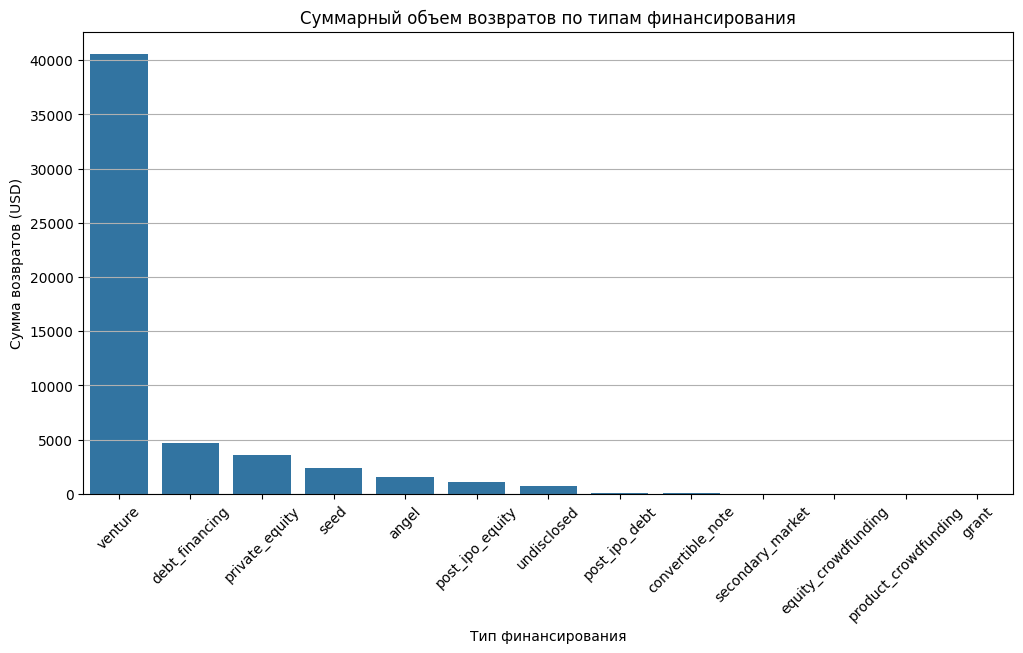

In [61]:
# Построим столбчатую диаграмму для визуализации
plt.figure(figsize=(12, 6))
sns.barplot(x=cb_returns_summary.index, y=cb_returns_summary.values)
plt.title('Суммарный объем возвратов по типам финансирования')
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма возвратов (USD)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Промежуточный вывод

По результатам анализа возвратов по типам финансирования можно сделать следующие выводы:   
- Наибольшие суммы возвратов приходятся на типы финансирования: `venture`, `debt_financing` и `private_equity`.   
- Наименьшие суммы возвратов у типов финансирования: `equity_crowdfunding`, `product_crowdfunding` и `grant`.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Главные вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [48]:
# Для каждой компании расчитаем средний объем одного раунда финансирования
df_filtered['avg_funding_per_round'] = (df_filtered['funding_total_usd'] / df_filtered['funding_rounds']).round(2)
df_filtered['funding_year'] = df_filtered['mid_funding_at'].dt.year
display(df_filtered[['name', 'funding_year', 'funding_total_usd', 'funding_rounds', 'avg_funding_per_round']].head(10).sort_values(by='avg_funding_per_round', ascending=False))

,name,funding_year,funding_total_usd,funding_rounds,avg_funding_per_round
5,Xavier University,2014,19000000,1.0,19000000.00
2,DuPont,2009,9000000,1.0,9000000.00
7,Duke University,2014,8700000,1.0,8700000.00
8,"Virginia Commonwealth University, Richmond",2014,6000000,1.0,6000000.00
6,Tulane University,2013,12000000,4.0,3000000.00
11,Mayne Pharma,2012,2705000,1.0,2705000.00
3,University of Michigan,2013,7700000,3.0,2566666.67
1,University of New Brunswick,2014,2000000,1.0,2000000.00
9,WeGame,2007,3500000,2.0,1750000.00
4,Case Western Reserve University,2014,540000,1.0,540000.00


Средний размер финансирования одного раунда по годам:


funding_year
1999    3736726.49
2000    4260524.66
2001    4701512.26
2002    4108853.34
2003    3434445.95
2004    4807757.03
2005    5398425.46
2006    4984300.73
2007    3954843.84
2008    3463412.46
2009    2972318.34
2010    2709606.11
2011    2270150.31
2012    1891390.77
2013    1842020.63
2014    2301285.36
Name: avg_funding_per_round, dtype: float64

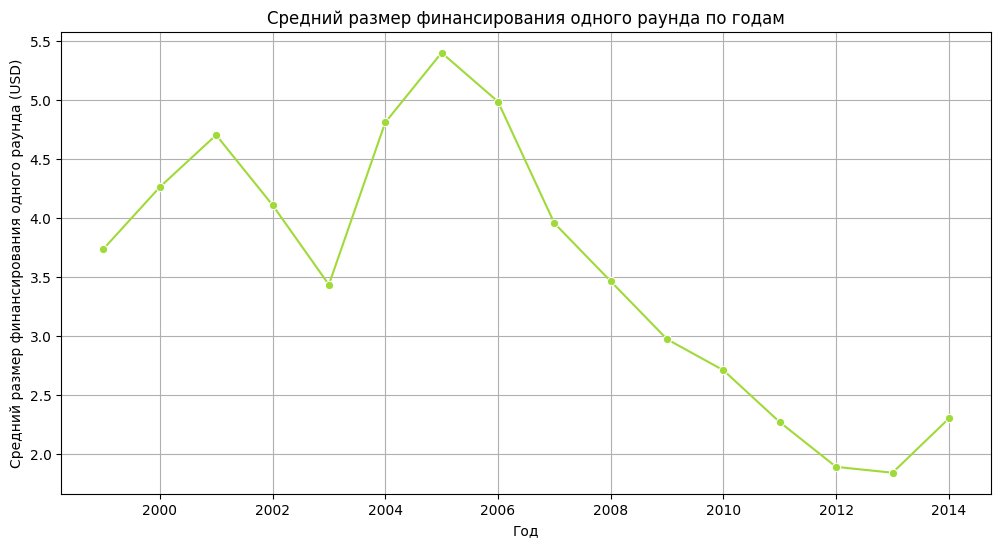

In [49]:
# Посчитаем средний размер финансирования одного раунда по годам
avg_funding_per_round_by_year = df_filtered.groupby('funding_year')['avg_funding_per_round'].mean().round(2)
print("Средний размер финансирования одного раунда по годам:")
display(avg_funding_per_round_by_year)

# Построим линейный график для визуализации
plt.figure(figsize=(12, 6))
sns.lineplot(x=avg_funding_per_round_by_year.index, y=avg_funding_per_round_by_year.values / 1000000, marker='o', color=sns.color_palette('viridis')[5])
plt.title('Средний размер финансирования одного раунда по годам')
plt.xlabel('Год')
plt.ylabel('Средний размер финансирования одного раунда (USD)')
plt.grid()
plt.show()

Самый быстрый рост финансирования наблюдался с 2003 по 2005 годы.
Самый пик финансирования в рамках одного раунда был в 2005 году и заметно снижался до 2013 года.   
С 2013 по 2014 год наблюдается небольшой рост.

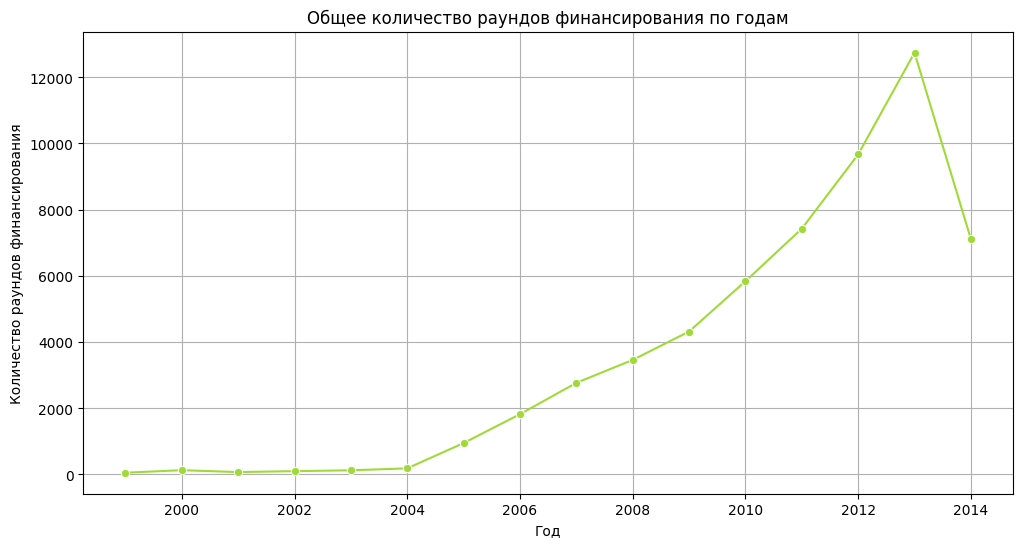

In [50]:
# Построим график общего количества раундов за каждый год
funding_rounds_per_year = df_filtered.groupby('funding_year')['funding_rounds'].sum()
plt.figure(figsize=(12, 6))
sns.lineplot(x=funding_rounds_per_year.index, y=funding_rounds_per_year.values, marker='o', color=sns.color_palette('viridis')[5])
plt.title('Общее количество раундов финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Количество раундов финансирования')
plt.grid()
plt.show()

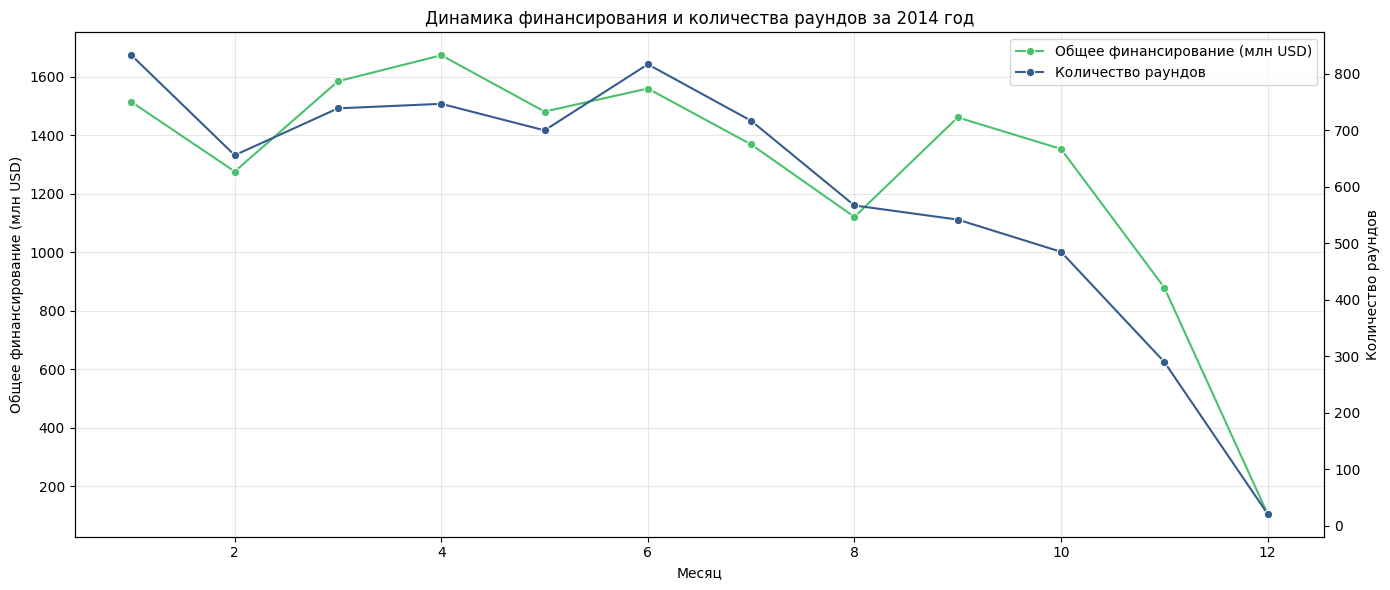

In [51]:
# Динамика финансирования и количества раундов за 2014 год 
funding_2014 = (
    df_filtered.loc[df_filtered['funding_year'] == 2014]
      .assign(month=lambda d: d['mid_funding_at'].dt.month)
      .groupby('month', as_index=False)
      .agg(
          total_funding_usd=('funding_total_usd', 'sum'),
          total_funding_rounds=('funding_rounds', 'sum')
      )
)

# Для читаемости переведём суммы в миллионы USD
funding_2014['total_funding_usd_mln'] = funding_2014['total_funding_usd'] / 1_000_000

fig, ax1 = plt.subplots(figsize=(14, 6))
palette = sns.color_palette('viridis', n_colors=6)

# Сумма финансирования
sns.lineplot(
    data=funding_2014, x='month', y='total_funding_usd_mln',
    marker='o', color=palette[4], ax=ax1, label='Общее финансирование (млн USD)', legend=False
)
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Общее финансирование (млн USD)')
ax1.grid(True, which='both', axis='both', alpha=0.3)

# Количество раундов
ax2 = ax1.twinx()
sns.lineplot(
    data=funding_2014, x='month', y='total_funding_rounds',
    marker='o', color=palette[1], ax=ax2, label='Количество раундов', legend=False
)
ax2.set_ylabel('Количество раундов')

# Легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Динамика финансирования и количества раундов за 2014 год')
plt.tight_layout()
plt.show()

### Промежуточный вывод

В рамках одного раундана максимальный типичный размер средств был в 2005 году и составил 5,39 млн долларов.
За 2014 год наблюдения показывают, что количество раундов финансирования было высоким с начала года и незначительно варьировалось,    
достигнув пика в июне, а затем постепенно снижалось к концу года. Количество финансирования практически корелировано с количеством раундов,   
что указывает на стабильный интерес инвесторов к стартапам в этот период.    
С сентября начинается заметное падение в обоих показателях, что может свидетельствовать о сезонных колебаниях или о том, что количество собранных данных    
было недостаточным.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

In [52]:
# Составим сводную таблицу суммарного общего размера финансирования 'funding_total_usd', по годам и сегментам рынка
funding_pivot = pd.pivot_table(
    df_filtered,
    values='funding_total_usd',
    index='funding_year',
    columns='market',
    aggfunc='sum',
    fill_value=0
).sort_index()
display(funding_pivot)

market,Advertising,Analytics,Apps,Automotive,Big Data,Biotechnology,Clean Technology,Cloud Computing,Consulting,Curated Web,...,Software,Sports,Startups,Technology,Travel,Video,Web Hosting,mid,niche,unknown
funding_year,,,,,,,,,,,,,,,,,,,,,
1999,350000,10774916,0,0,0,0,0,0,115200,9250000,...,50034643,0,0,6000000,0,0,3600000,3500000,0,9432055
2000,14470000,14822803,0,0,0,0,0,11500000,4500000,32200000,...,31732640,0,0,0,50230,0,155000,145286389,28600000,13039560
2001,8778321,0,0,0,0,0,0,0,0,305000,...,50086279,0,0,22160000,0,0,15000000,9441026,44020000,51540483
2002,24500000,7500000,0,0,0,0,0,0,0,22950000,...,125026395,200000,0,11000000,0,0,0,18885799,0,44606286
2003,10500000,3840000,0,4530000,0,42031178,2175000,0,0,48871350,...,66086037,0,0,0,0,5000000,0,62738404,0,4155202
2004,6000000,3000000,0,0,0,45119644,19427954,0,0,131850000,...,140823795,0,0,1750000,10230000,14704000,27000000,75038160,0,83428435
2005,101696022,79014044,0,22500000,0,290763582,19420000,0,64862000,84650000,...,1147861822,1882200,0,20728425,27830000,6470551,314732632,257362636,20600000,121621681
2006,222727774,139701311,1310600,12660000,0,450524428,25870000,9951809,67930188,344157822,...,1822635854,7000000,0,22785000,11700000,55321772,308243433,433722579,25579999,255542109
2007,503704331,48829000,20250000,37712601,7780000,776095385,228545046,20354343,103839345,615316482,...,1892676357,42401580,0,16990209,55001724,108500644,124169223,654212891,44494637,57532468


In [53]:
# Оставим сегменты, которые показывали рост с 2013 по 2014 год
funding_pivot_13_14 = funding_pivot.loc[:,funding_pivot.loc[2014] > funding_pivot.loc[2013]]

# Исключаем сегменты 'mid', 'niche' и 'unknown'
mass_segments = [col for col in funding_pivot_13_14.columns if col not in ('mid', 'niche', 'unknown')] 
funding_pivot_growth = funding_pivot_13_14[mass_segments]

display(funding_pivot_growth)

market,Apps,Internet,Medical,Nonprofits,Real Estate,SaaS,Sports,Startups,Technology,Video
funding_year,,,,,,,,,,
1999,0,0,0,0,250000,0,0,0,6000000,0
2000,0,10000000,24000000,6500000,2500000,0,0,0,0,0
2001,0,0,0,0,0,0,0,0,22160000,0
2002,0,1100000,0,0,5275000,2000000,200000,0,11000000,0
2003,0,0,0,0,6292200,0,0,0,0,5000000
2004,0,10500000,0,0,0,0,0,0,1750000,14704000
2005,0,1775000,11090000,17051520,250000,5240000,1882200,0,20728425,6470551
2006,1310600,21400000,20250000,12880000,22080000,4791121,7000000,0,22785000,55321772
2007,20250000,4495379,2100000,200000,56220000,74252585,42401580,0,16990209,108500644


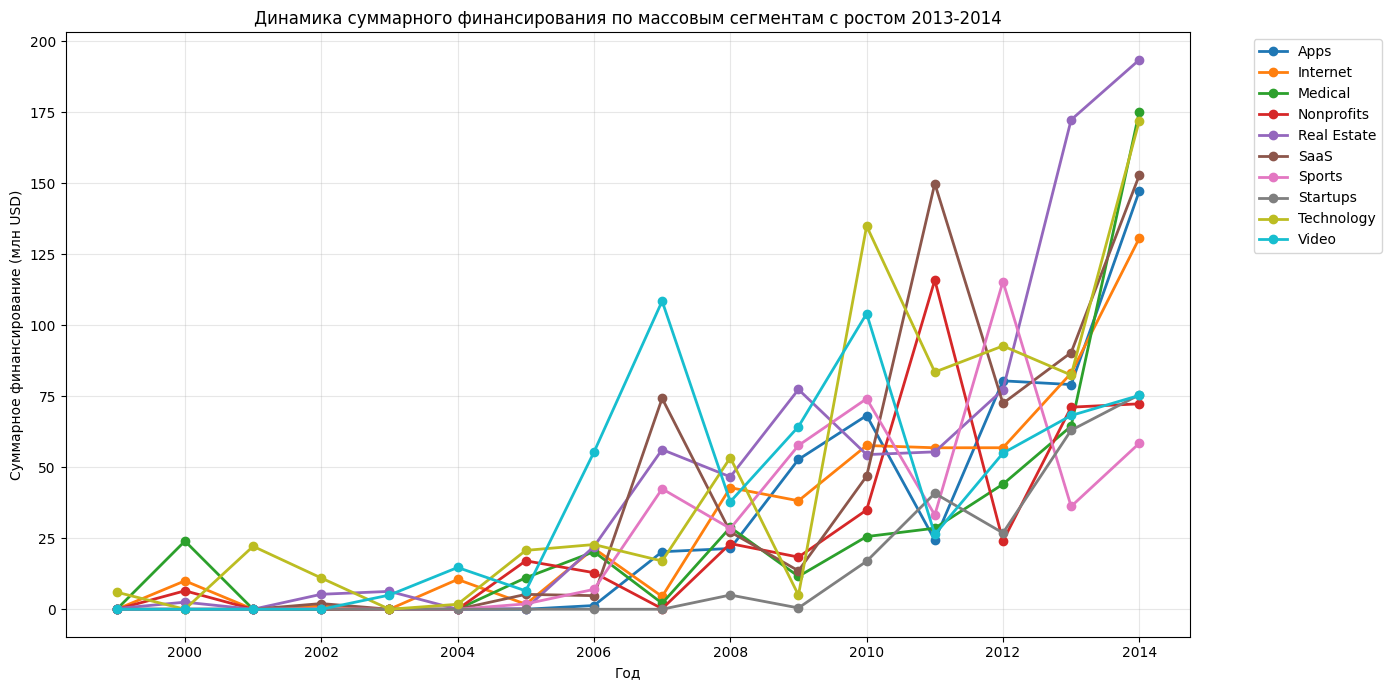

In [54]:
# Построим график динамики финансирования для отобранных массовых сегментов
plt.figure(figsize=(14, 7))
for segment in funding_pivot_growth.columns:
    plt.plot(funding_pivot_growth.index, 
             funding_pivot_growth[segment] / 1_000_000, 
             marker='o', label=segment, linewidth=2)

plt.title('Динамика суммарного финансирования по массовым сегментам с ростом 2013-2014')
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование (млн USD)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Промежуточный вывод

После отбора массовых сегментов с ростом финансирования с 2013 по 2014 год, были выявлено:
- Самый высокий показатель финансирования имеет сегмент "Software".
- Быстрый рост наблюдается в сегментах "Medical", "Technology", "Saas", "Apps" и "Internet". 
- Сегменты "Video", "Startups", "Sports" имеют более умеренный рост, но также показывают положительную динамику.
- Сегмент "Nonprofits" имеет самый плоский рост среди отобранных сегментов, что может указывать на стабильный, но незначительный интерес инвесторов к этому сектору.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

In [55]:
# Общее финансирование по годам и сегментам из df_filtered
funding_by_year_type = df_filtered.groupby('funding_year')[funding_type_cols].sum()

# Преобразуем возвраты из млн в доллары для соответствия первому датасету
returns_by_year_type = df_cb_returns * 1_000_000

# Рассчитаем долю возвратов
normalized_returns = (returns_by_year_type / (funding_by_year_type + 1e-60) * 100).round(2)

# Заменим аномально большие значения (200% возврата) на NaN
# Используем np.nan для корректной работы matplotlib
normalized_returns = normalized_returns.where(normalized_returns <= 200, np.nan) 

display(normalized_returns)

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000,99.65,19.05,0.00,43.78,0.00,123.71,24.65,0.0,0.00,27.11,0.00,2.59,0.00
2001,70.26,10.84,0.00,32.70,NaN,54.42,118.00,0.0,0.00,NaN,0.00,NaN,0.00
2002,69.62,69.91,0.00,60.89,NaN,23.90,113.67,0.0,9.18,113.33,0.00,NaN,0.00
2003,70.83,68.42,0.00,91.44,NaN,103.81,36.78,0.0,NaN,NaN,0.00,NaN,0.00
2004,58.05,78.54,0.00,71.08,NaN,64.47,83.35,0.0,NaN,NaN,0.00,NaN,0.00
2005,65.00,59.38,0.00,34.63,NaN,55.08,49.37,0.0,48.00,73.19,0.00,NaN,0.00
2006,86.44,39.29,20.36,110.46,15.07,97.96,65.61,0.0,55.45,NaN,0.00,NaN,0.00
2007,34.82,37.94,NaN,53.66,28.92,67.43,74.06,0.0,121.76,NaN,0.00,NaN,0.00
2008,28.84,26.09,NaN,35.10,11.14,145.02,40.13,0.0,NaN,NaN,0.00,NaN,0.00


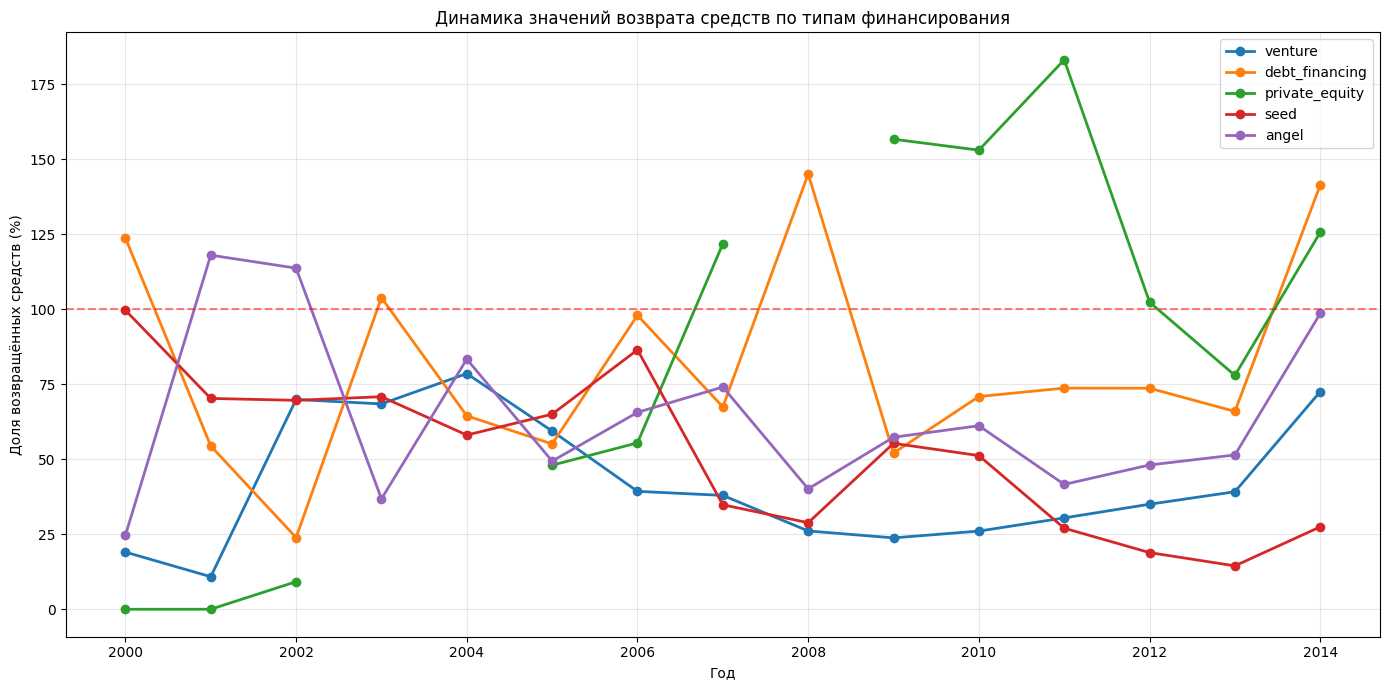

In [56]:
# Отберём интересующие типы финансирования
target_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
normalized_returns_selected = normalized_returns[target_types]

# Построим график динамики возвратов, пропуски останутся на графике
plt.figure(figsize=(14, 7))
for f_type in normalized_returns_selected.columns:
    plt.plot(normalized_returns_selected.index, 
             normalized_returns_selected[f_type], 
             marker='o', label=f_type, linewidth=2)


plt.title('Динамика значений возврата средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возвращённых средств (%)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='100% возврат') # полный возврат инвестиций
plt.tight_layout()
plt.show()

In [57]:
# Посчитаем статистику по каждому типу
display(normalized_returns_selected.mean().sort_values(ascending=False).round(2))

private_equity    86.08
debt_financing    80.89
angel             64.25
seed              51.86
venture           42.43
dtype: float64

### Промежуточный вывод

Наиболее устойчивый рост показателя:
- Типы финансирования с положительной динамикой и стабильными показателями возврата демонстрируют привлекательность для инвесторов
- Значения близкие к 100% указывают на полный возврат вложенных средств
- Значения выше 100% могут свидетельствовать о прибыли от инвестиций. К ним относятся `private_equity` и `debt_financing`, они чаще всего показывают рост.

Особенности по типам:
- Высокие показатели возврата у `private_equity` и `debt_financing`, однако `private_equity` показывает значительную волатильность.
- Низкие показатели у `seed` и `angel` могут указывать на длительный период окупаемости или высокие риски. `angel` показывает рост в последние годы.
- Волатильность показателей в принципе, может указывать на нестабильность рынка или влияние внешних факторов.

Аномально высокие значения (> 200%) были заменены на пропуски, так как они могут быть связаны с ошибками. На графике это отражено пропусками.


## Шаг 5. Итоговый вывод и рекомендации

По результатам анализа можно сделать следующие рекомендации:
- Отрасль для инвестирования: Рекомендуется обратить внимание на сегменты "Software", "Medical", "Technology", "Saas", "Apps" и "Internet", которые демонстрируют быстрый и уверенный рост финансирования.
- Тип финансирования: Наиболее уместными типами финансирования для инвестирования являются "venture", "debt_financing" и "private_equity", так как они привлекают наибольшие суммы финансирования и показывают устойчивый рост возврата средств. Однако, следует учитывать волатильность показателей, особенно у "private_equity".    
"venture" хоть и привлекает огромные суммы, но возврат по нему менее 100%, что может указывать на отсутствие прибыли.
Итоговый вывод и рекомендации:
Шаги:
1. Загрузка и предобработка данных: Были обработаны пропуски, приведены типы данных к соответствующим форматам, удалены дубликаты и аномальные значения.
2. Инжиниринг признаков: Компании были разделены на группы по срокам финансирования и сегментам рынка.
3. Работа с выбросами и анализ: Были выявлены и помечены выбросы, проведён анализ типов финансирования по объёму и популярности.
4. Анализ динамики: Исследована динамика предоставления финансирования по годам, а также годовая динамика доли возвращённых средств по сегментам финансирования.
Выводы, сделанные в ходе анализа, в целом согласуются между собой и подтверждают рекомендации по инвестированию в определённые отрасли и сегменты.   
Однако, необходимо учитывать волатильность показателей и возможные риски, связанные с инвестициями в определённые сегменты рынка.


**Основные общие рекомендации**: 
- Инвестировать в сегменты с быстрым ростом финансирования - "Software", "Medical", "Technology", "Saas", "Apps" и "Internet".
- Предпочтение отдавать типам финансирования с устойчивым ростом возврата средств - "angel", "debt_financing" и "private_equity", с учётом волатильности показателей.
